# Fraud Anomaly Detection

## Business Objective

This project explores how unsupervised machine learning can be used to identify unusual patterns in highly imbalanced financial transaction data.

The objective is to detect transactions that deviate from normal behaviour, evaluate how effectively anomaly detection methods identify fraudulent activity, and analyse the trade-off between detecting fraud and generating false positives.

In [33]:
!pip install -q kagglehub

In [34]:
import kagglehub
import pandas as pd
import os

# Download the latest version of the Credit Card Fraud Detection dataset
dataset_path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset path: /kaggle/input/creditcardfraud
Files: ['creditcard.csv']


In [35]:
# Load the dataset
csv_path = os.path.join(dataset_path, "creditcard.csv")
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution (%):")
print((df["Class"].value_counts(normalize=True) * 100).round(4))

Missing values: 0
Duplicate rows: 1081

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (%):
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


In [37]:
# Examine the class distribution among exact duplicate rows
duplicate_rows = df[df.duplicated()]

print("Duplicate rows:", len(duplicate_rows))

print("\nDuplicate rows by class:")
print(duplicate_rows["Class"].value_counts())

print("\nDuplicate rows by class (%):")
print(
    (duplicate_rows["Class"].value_counts(normalize=True) * 100).round(2)
)

Duplicate rows: 1081

Duplicate rows by class:
Class
0    1062
1      19
Name: count, dtype: int64

Duplicate rows by class (%):
Class
0    98.24
1     1.76
Name: proportion, dtype: float64


## Initial Data Quality Assessment

The dataset contains 284,807 credit card transactions across 31 variables.

The target variable is highly imbalanced:

- 284,315 legitimate transactions (99.8273%)
- 492 fraudulent transactions (0.1727%)

No missing values were identified.

A total of 1,081 exact duplicate rows were detected, including 19 fraudulent observations. Exact duplicates will be removed to avoid giving repeated observations disproportionate influence during the analysis.

The `Class` variable will not be used to train the unsupervised anomaly detection models. It will be retained exclusively as ground truth for evaluating how effectively the models identify known fraudulent transactions.

In [38]:
# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

print("Original transactions:", len(df))
print("Clean transactions:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

print("\nClass distribution after removing duplicates:")
print(df_clean["Class"].value_counts())

Original transactions: 284807
Clean transactions: 283726
Rows removed: 1081

Class distribution after removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


In [39]:
print("Columns and data types:")
print(df_clean.dtypes)

print("\nFeature ranges:")
print(
    df_clean[["Time", "Amount"]]
    .agg(["min", "max", "mean", "median"])
    .round(2)
)

Columns and data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Feature ranges:
             Time    Amount
min          0.00      0.00
max     172792.00  25691.16
mean     94811.08     88.47
median   84692.50     22.00


In [40]:
print("Skewness:")

print(
    df_clean[["Time", "Amount"]]
    .skew()
    .round(2)
)

Skewness:
Time      -0.04
Amount    16.98
dtype: float64


In [41]:
import numpy as np

# Create a log-transformed version of transaction amount
df_clean["LogAmount"] = np.log1p(df_clean["Amount"])

print("Original Amount skewness:", round(df_clean["Amount"].skew(), 2))
print("LogAmount skewness:", round(df_clean["LogAmount"].skew(), 2))

Original Amount skewness: 16.98
LogAmount skewness: 0.16


## Feature Preparation

The original transaction amount showed extreme positive skewness. A logarithmic transformation reduced its skewness from 16.98 to 0.16 while preserving high-value transactions.

For anomaly detection, the model features include `Time`, the anonymised numerical variables `V1` to `V28`, and the transformed `LogAmount`.

The original `Amount` variable is excluded from modelling to avoid duplicating the same information, while `Class` is retained only for evaluation and is not provided to the unsupervised models.

In [42]:
from sklearn.preprocessing import StandardScaler

# Define model features and evaluation labels
feature_columns = (
    ["Time"] +
    [f"V{i}" for i in range(1, 29)] +
    ["LogAmount"]
)

X = df_clean[feature_columns].copy()
y = df_clean["Class"].copy()

# Standardise features for consistent model comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Model feature shape:", X_scaled.shape)
print("Number of features:", X_scaled.shape[1])
print("Feature means:", X_scaled.mean(axis=0).mean().round(4))
print("Average feature standard deviation:", X_scaled.std(axis=0).mean().round(4))

Model feature shape: (283726, 30)
Number of features: 30
Feature means: 0.0
Average feature standard deviation: 1.0


## Model Comparison Strategy

Isolation Forest and Local Outlier Factor (LOF) will be compared on the same fixed random sample of transactions.

A 50,000-transaction sample is used to keep the LOF nearest-neighbour calculations computationally manageable while preserving a substantial and naturally imbalanced evaluation set.

The sample is selected without using the fraud labels. The `Class` variable remains excluded from model training and is used only after modelling to evaluate anomaly detection performance.

In [43]:
# Create a fixed random sample for model comparison
rng = np.random.default_rng(42)

sample_positions = rng.choice(
    len(X_scaled),
    size=50000,
    replace=False
)

X_sample = X_scaled[sample_positions]
y_sample = y.iloc[sample_positions].to_numpy()

print("Sample transactions:", len(X_sample))
print("Legitimate transactions:", (y_sample == 0).sum())
print("Fraudulent transactions:", (y_sample == 1).sum())

print(
    "Fraud prevalence (%):",
    round((y_sample == 1).mean() * 100, 4)
)

Sample transactions: 50000
Legitimate transactions: 49920
Fraudulent transactions: 80
Fraud prevalence (%): 0.16


## Isolation Forest

Isolation Forest identifies anomalies by isolating observations through random partitioning.

For a fair comparison with Local Outlier Factor, both models use the same fixed expected anomaly proportion of 0.2%.

The fraud labels are not used during model fitting. They are used only afterwards to evaluate whether the detected anomalies correspond to known fraudulent transactions.

In [44]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

if_predictions_raw = isolation_forest.fit_predict(X_sample)

# Convert scikit-learn output:
# -1 = anomaly -> 1
#  1 = normal  -> 0
if_predictions = (if_predictions_raw == -1).astype(int)

print("Transactions analysed:", len(if_predictions))
print("Anomalies detected:", if_predictions.sum())
print(
    "Detected anomaly rate (%):",
    round(if_predictions.mean() * 100, 4)
)

Transactions analysed: 50000
Anomalies detected: 100
Detected anomaly rate (%): 0.2


In [45]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Evaluate Isolation Forest against known fraud labels
if_precision = precision_score(y_sample, if_predictions)
if_recall = recall_score(y_sample, if_predictions)
if_f1 = f1_score(y_sample, if_predictions)

tn, fp, fn, tp = confusion_matrix(
    y_sample,
    if_predictions
).ravel()

print("Isolation Forest Results")
print("------------------------")
print("True positives:", tp)
print("False positives:", fp)
print("False negatives:", fn)
print("True negatives:", tn)

print("\nPrecision:", round(if_precision, 3))
print("Recall:", round(if_recall, 3))
print("F1-score:", round(if_f1, 3))

Isolation Forest Results
------------------------
True positives: 18
False positives: 82
False negatives: 62
True negatives: 49838

Precision: 0.18
Recall: 0.225
F1-score: 0.2


### Isolation Forest Performance

Isolation Forest detected 100 anomalies from the 50,000 sampled transactions.

When compared with the known fraud labels:

- True positives: 18
- False positives: 82
- False negatives: 62
- Precision: 0.180
- Recall: 0.225
- F1-score: 0.200

The model identifies some fraudulent transactions, but most detected anomalies are legitimate transactions and a substantial proportion of known fraud remains undetected.

This illustrates an important distinction between statistical anomaly detection and fraud detection: unusual behaviour is not necessarily fraudulent behaviour.

In [46]:
from sklearn.neighbors import LocalOutlierFactor

# Train Local Outlier Factor using the same anomaly proportion
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.002,
    n_jobs=-1
)

lof_predictions_raw = lof.fit_predict(X_sample)

# Convert scikit-learn output:
# -1 = anomaly -> 1
#  1 = normal  -> 0
lof_predictions = (lof_predictions_raw == -1).astype(int)

print("Transactions analysed:", len(lof_predictions))
print("Anomalies detected:", lof_predictions.sum())
print(
    "Detected anomaly rate (%):",
    round(lof_predictions.mean() * 100, 4)
)

Transactions analysed: 50000
Anomalies detected: 100
Detected anomaly rate (%): 0.2


In [47]:
# Evaluate Local Outlier Factor against known fraud labels
lof_precision = precision_score(y_sample, lof_predictions)
lof_recall = recall_score(y_sample, lof_predictions)
lof_f1 = f1_score(y_sample, lof_predictions)

tn, fp, fn, tp = confusion_matrix(
    y_sample,
    lof_predictions
).ravel()

print("Local Outlier Factor Results")
print("----------------------------")
print("True positives:", tp)
print("False positives:", fp)
print("False negatives:", fn)
print("True negatives:", tn)

print("\nPrecision:", round(lof_precision, 3))
print("Recall:", round(lof_recall, 3))
print("F1-score:", round(lof_f1, 3))

Local Outlier Factor Results
----------------------------
True positives: 2
False positives: 98
False negatives: 78
True negatives: 49822

Precision: 0.02
Recall: 0.025
F1-score: 0.022


### Local Outlier Factor Performance

Local Outlier Factor detected 100 anomalies from the same 50,000-transaction sample.

When compared with the known fraud labels:

- True positives: 2
- False positives: 98
- False negatives: 78
- Precision: 0.020
- Recall: 0.025
- F1-score: 0.022

Under the same anomaly-rate assumption, LOF performed substantially worse than Isolation Forest. Most transactions identified as locally unusual were legitimate, while 78 of the 80 known fraudulent transactions remained undetected.

The result reinforces that local statistical unusualness does not necessarily correspond to fraudulent behaviour.

In [48]:
model_comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Local Outlier Factor"],
    "True Positives": [18, 2],
    "False Positives": [82, 98],
    "False Negatives": [62, 78],
    "Precision": [if_precision, lof_precision],
    "Recall": [if_recall, lof_recall],
    "F1-score": [if_f1, lof_f1]
})

model_comparison.round(3)

,Model,True Positives,False Positives,False Negatives,Precision,Recall,F1-score
0,Isolation Forest,18,82,62,0.18,0.225,0.200
1,Local Outlier Factor,2,98,78,0.02,0.025,0.022


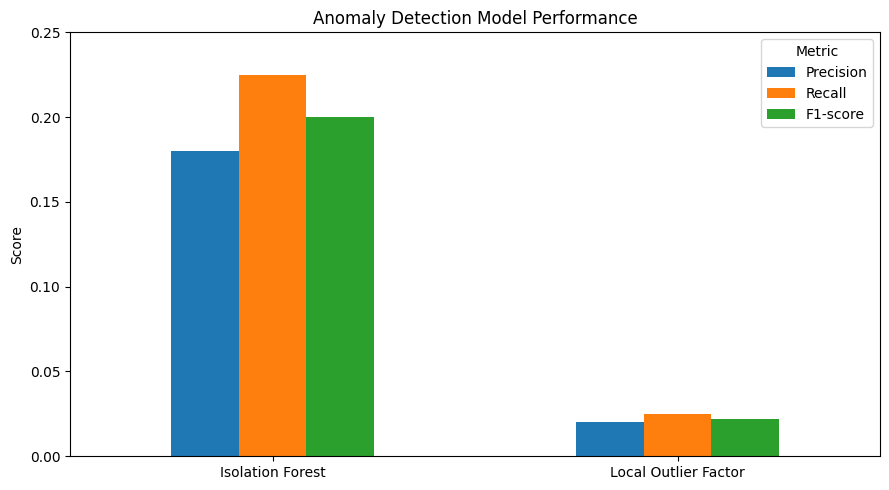

In [49]:
import matplotlib.pyplot as plt

# Compare model performance
metrics_comparison = model_comparison.set_index("Model")[
    ["Precision", "Recall", "F1-score"]
]

ax = metrics_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Anomaly Detection Model Performance")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 0.25)
ax.legend(title="Metric")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [50]:
# Compare which transactions were flagged by each model
anomaly_overlap = ((if_predictions == 1) & (lof_predictions == 1)).sum()

if_only = ((if_predictions == 1) & (lof_predictions == 0)).sum()
lof_only = ((if_predictions == 0) & (lof_predictions == 1)).sum()

print("Anomalies detected by both models:", anomaly_overlap)
print("Detected only by Isolation Forest:", if_only)
print("Detected only by LOF:", lof_only)

Anomalies detected by both models: 15
Detected only by Isolation Forest: 85
Detected only by LOF: 85


In [51]:
both_mask = (if_predictions == 1) & (lof_predictions == 1)
if_only_mask = (if_predictions == 1) & (lof_predictions == 0)
lof_only_mask = (if_predictions == 0) & (lof_predictions == 1)

print("Frauds detected by both models:", y_sample[both_mask].sum())
print("Frauds detected only by Isolation Forest:", y_sample[if_only_mask].sum())
print("Frauds detected only by LOF:", y_sample[lof_only_mask].sum())

Frauds detected by both models: 0
Frauds detected only by Isolation Forest: 18
Frauds detected only by LOF: 2


### Anomaly Overlap Analysis

The two models showed very limited agreement in the transactions identified as anomalous.

- 15 transactions were flagged by both models.
- 85 were detected only by Isolation Forest.
- 85 were detected only by Local Outlier Factor.

Notably, none of the 15 anomalies detected by both models corresponded to known fraud.

All 18 fraudulent transactions identified by Isolation Forest came from anomalies detected exclusively by that model, while the two fraud cases found by LOF were also unique to LOF.

This indicates that the two algorithms capture substantially different notions of unusual behaviour. In this sample, the anomaly patterns identified by Isolation Forest were considerably more aligned with known fraudulent activity.

In [52]:
# Build an analysis table for the sampled transactions
sample_analysis = df_clean.iloc[sample_positions].copy().reset_index(drop=True)

sample_analysis["IsolationForest"] = if_predictions
sample_analysis["LOF"] = lof_predictions

# Measure overall distance from typical standardised feature values
sample_analysis["MeanAbsZ"] = np.mean(np.abs(X_sample), axis=1)
sample_analysis["MaxAbsZ"] = np.max(np.abs(X_sample), axis=1)

# Classify transactions according to which model flagged them
sample_analysis["DetectionGroup"] = np.select(
    [
        (if_predictions == 1) & (lof_predictions == 1),
        (if_predictions == 1) & (lof_predictions == 0),
        (if_predictions == 0) & (lof_predictions == 1)
    ],
    [
        "Both models",
        "Isolation Forest only",
        "LOF only"
    ],
    default="Not flagged"
)

group_summary = (
    sample_analysis
    .groupby("DetectionGroup")
    .agg(
        Transactions=("Class", "size"),
        Frauds=("Class", "sum"),
        FraudRatePct=("Class", lambda x: x.mean() * 100),
        MedianAmount=("Amount", "median"),
        MeanAbsZ=("MeanAbsZ", "mean"),
        MedianMaxAbsZ=("MaxAbsZ", "median")
    )
    .round(3)
)

group_summary

,Transactions,Frauds,FraudRatePct,MedianAmount,MeanAbsZ,MedianMaxAbsZ
DetectionGroup,,,,,,
Both models,15,0,0.000,1210.00,6.612,32.866
Isolation Forest only,85,18,21.176,240.38,3.853,16.800
LOF only,85,2,2.353,4.45,0.701,2.026
Not flagged,49815,60,0.120,22.00,0.666,1.981


### Characteristics of Detected Anomalies

The transactions identified by the two models exhibit substantially different characteristics.

Transactions detected by both models were the most globally extreme observations in the sample, with a mean absolute standardised deviation of 6.612 and a median maximum deviation of 32.866. Their median transaction amount was also unusually high at 1,210.00. However, none of these transactions were labelled as fraud.

Isolation Forest produced a much more fraud-enriched set of unique anomalies. Among the 85 transactions detected exclusively by Isolation Forest, 18 were fraudulent, representing a fraud rate of 21.176%. These observations also showed strong global deviation from typical feature values.

By contrast, transactions detected exclusively by Local Outlier Factor were much less extreme globally. Their mean absolute standardised deviation was only 0.701 and their median transaction amount was 4.45. Only 2 of the 85 transactions in this group were fraudulent.

The results suggest that LOF is identifying observations that are unusual relative to their local neighbourhood, whereas Isolation Forest is capturing broader multidimensional deviations that, in this dataset, are more strongly associated with known fraudulent activity.

Importantly, the transactions considered most statistically extreme were not necessarily fraudulent. This reinforces the distinction between anomaly detection and fraud identification.

## Alert-Rate Sensitivity Analysis

An anomaly detection system must balance fraud detection against the operational cost of investigating false positives.

Rather than selecting a single alert threshold based on the known fraud labels, the Isolation Forest anomaly ranking is evaluated at several predefined alert rates.

This analysis shows how increasing the number of transactions selected for investigation affects precision, recall and F1-score.

In [53]:
# Obtain continuous anomaly scores
# Higher values indicate greater anomaly
if_anomaly_scores = -isolation_forest.score_samples(X_sample)

alert_rates = [0.001, 0.002, 0.005, 0.01]

sensitivity_results = []

for alert_rate in alert_rates:
    n_alerts = int(len(X_sample) * alert_rate)

    # Select the most anomalous transactions
    alert_indices = np.argsort(if_anomaly_scores)[-n_alerts:]

    predictions = np.zeros(len(X_sample), dtype=int)
    predictions[alert_indices] = 1

    tn, fp, fn, tp = confusion_matrix(
        y_sample,
        predictions
    ).ravel()

    sensitivity_results.append({
        "Alert Rate (%)": alert_rate * 100,
        "Alerts": n_alerts,
        "True Positives": tp,
        "False Positives": fp,
        "Precision": precision_score(y_sample, predictions),
        "Recall": recall_score(y_sample, predictions),
        "F1-score": f1_score(y_sample, predictions)
    })

sensitivity_table = pd.DataFrame(sensitivity_results)

sensitivity_table.round(3)

,Alert Rate (%),Alerts,True Positives,False Positives,Precision,Recall,F1-score
0,0.1,50,14,36,0.280,0.175,0.215
1,0.2,100,18,82,0.180,0.225,0.200
2,0.5,250,27,223,0.108,0.338,0.164
3,1.0,500,44,456,0.088,0.550,0.152


### Alert-Rate Trade-off

The sensitivity analysis shows a clear operational trade-off between fraud detection and investigation workload.

At a 0.1% alert rate, the model generated only 50 alerts and achieved the highest precision (0.280) and F1-score (0.215), identifying 14 of the 80 known fraud cases.

Increasing the alert rate improved recall but substantially increased the number of false positives. At a 1.0% alert rate, the model detected 44 fraudulent transactions, reaching a recall of 0.550, but produced 456 false positives.

There is therefore no universally optimal threshold. The appropriate alert rate depends on the relative cost of investigating legitimate transactions versus the cost of failing to detect fraud.

In a real fraud-monitoring environment, threshold selection should be aligned with available investigation capacity, financial risk and business tolerance for missed fraud.

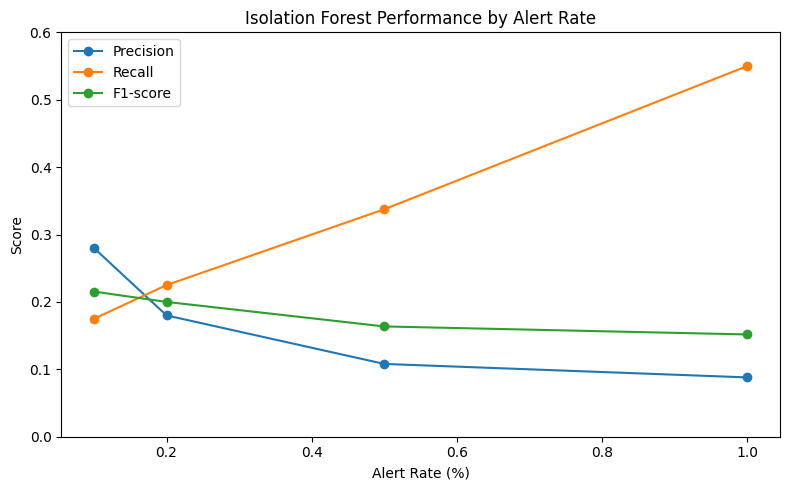

In [54]:
# Visualise the precision-recall trade-off across alert rates
plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity_table["Alert Rate (%)"],
    sensitivity_table["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    sensitivity_table["Alert Rate (%)"],
    sensitivity_table["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    sensitivity_table["Alert Rate (%)"],
    sensitivity_table["F1-score"],
    marker="o",
    label="F1-score"
)

plt.title("Isolation Forest Performance by Alert Rate")
plt.xlabel("Alert Rate (%)")
plt.ylabel("Score")
plt.ylim(0, 0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
from sklearn.metrics import average_precision_score

# Continuous anomaly scores
# Higher score = more anomalous
if_scores = -isolation_forest.score_samples(X_sample)
lof_scores = -lof.negative_outlier_factor_

# Threshold-independent ranking performance
if_ap = average_precision_score(y_sample, if_scores)
lof_ap = average_precision_score(y_sample, lof_scores)

baseline_ap = y_sample.mean()

print("Baseline fraud prevalence:", round(baseline_ap, 4))
print("Isolation Forest Average Precision:", round(if_ap, 4))
print("LOF Average Precision:", round(lof_ap, 4))

Baseline fraud prevalence: 0.0016
Isolation Forest Average Precision: 0.103
LOF Average Precision: 0.0046


### Ranking Performance: Average Precision

Average Precision was used to evaluate how effectively each model ranks known fraudulent transactions toward the most anomalous end of its scoring distribution, independently of a single alert threshold.

The baseline fraud prevalence in the evaluation sample is only 0.0016 (0.16%).

- Isolation Forest Average Precision: 0.1030
- Local Outlier Factor Average Precision: 0.0046
- Baseline prevalence: 0.0016

Isolation Forest therefore achieved an Average Precision approximately 64 times higher than the baseline prevalence, while LOF achieved approximately 2.9 times the baseline.

This provides stronger evidence that Isolation Forest ranks fraudulent transactions substantially more effectively than LOF across different possible alert thresholds, rather than performing better only at the initially selected 0.2% alert rate.

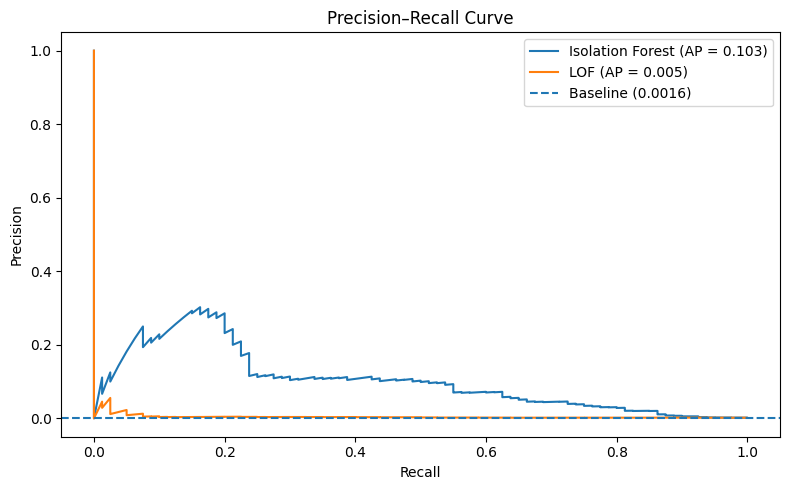

In [56]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall curves
if_precision_curve, if_recall_curve, _ = precision_recall_curve(
    y_sample,
    if_scores
)

lof_precision_curve, lof_recall_curve, _ = precision_recall_curve(
    y_sample,
    lof_scores
)

# Plot Precision-Recall curves
plt.figure(figsize=(8, 5))

plt.plot(
    if_recall_curve,
    if_precision_curve,
    label=f"Isolation Forest (AP = {if_ap:.3f})"
)

plt.plot(
    lof_recall_curve,
    lof_precision_curve,
    label=f"LOF (AP = {lof_ap:.3f})"
)

plt.axhline(
    y=baseline_ap,
    linestyle="--",
    label=f"Baseline ({baseline_ap:.4f})"
)

plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

### Precision–Recall Analysis

The Precision–Recall curves confirm the ranking advantage of Isolation Forest across a wide range of decision thresholds.

Isolation Forest maintains substantially higher precision than Local Outlier Factor for comparable levels of recall, while LOF remains much closer to the very low fraud-prevalence baseline.

This indicates that Isolation Forest is consistently more effective at prioritising fraudulent transactions toward the top of the anomaly ranking.

Given the extreme class imbalance of the dataset, Precision–Recall analysis is especially informative because it focuses directly on the model's ability to identify the rare fraudulent class without being dominated by the large number of legitimate transactions.

In [57]:
# Compare detected and missed fraud cases
sample_analysis["IF_AnomalyScore"] = if_scores

fraud_analysis = sample_analysis[
    sample_analysis["Class"] == 1
].copy()

fraud_analysis["DetectionStatus"] = np.where(
    fraud_analysis["IsolationForest"] == 1,
    "Detected fraud",
    "Missed fraud"
)

fraud_detection_summary = (
    fraud_analysis
    .groupby("DetectionStatus")
    .agg(
        Frauds=("Class", "size"),
        MedianAmount=("Amount", "median"),
        MeanAbsZ=("MeanAbsZ", "mean"),
        MedianMaxAbsZ=("MaxAbsZ", "median"),
        MedianAnomalyScore=("IF_AnomalyScore", "median")
    )
    .round(3)
)

fraud_detection_summary

,Frauds,MedianAmount,MeanAbsZ,MedianMaxAbsZ,MedianAnomalyScore
DetectionStatus,,,,,
Detected fraud,18,73.955,5.216,21.188,0.674
Missed fraud,62,2.110,1.775,8.015,0.560


### Detected vs. Missed Fraud

Fraudulent transactions detected by Isolation Forest were substantially more extreme than those the model failed to identify.

Detected fraud showed:

- A median transaction amount of 73.955, compared with 2.110 for missed fraud.
- A mean absolute standardised deviation of 5.216, compared with 1.775.
- A median maximum standardised deviation of 21.188, compared with 8.015.
- A higher median Isolation Forest anomaly score (0.674 versus 0.560).

These results suggest that Isolation Forest is most effective when fraudulent transactions differ strongly from the overall transaction pattern.

By contrast, fraud cases that more closely resemble legitimate behaviour are considerably harder for an unsupervised anomaly detector to identify.

This represents an important limitation of anomaly-based fraud detection: fraudulent behaviour is not always statistically extreme.

## Robustness Check on Unseen Data

The previous analysis evaluated outlier detection within a fixed transaction sample.

To assess whether the observed model differences generalise beyond the data used during fitting, an additional validation is performed using separate training and test sets.

Neither model receives the fraud labels during training. The `Class` variable is retained exclusively for evaluating anomaly-ranking performance on previously unseen transactions.

This validation complements the exploratory outlier analysis by testing whether the models can prioritise fraudulent activity in new data.

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Rebuild the 50,000-transaction sample using unscaled features
X_sample_raw = X.iloc[sample_positions].copy()
y_sample_raw = y.iloc[sample_positions].copy()

# Random train/test split
# Fraud labels do not influence how the split is created
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_sample_raw,
    y_sample_raw,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Fit the scaler only on training data
robust_scaler = StandardScaler()

X_train = robust_scaler.fit_transform(X_train_raw)
X_test = robust_scaler.transform(X_test_raw)

print("Training transactions:", len(X_train))
print("Test transactions:", len(X_test))

print("\nTraining fraud cases:", y_train.sum())
print("Test fraud cases:", y_test.sum())

print("\nTraining feature mean:", round(X_train.mean(), 4))
print("Training feature std:", round(X_train.std(), 4))

Training transactions: 35000
Test transactions: 15000

Training fraud cases: 56
Test fraud cases: 24

Training feature mean: -0.0
Training feature std: 1.0


In [59]:
# Train Isolation Forest only on the training set
if_robust = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

if_robust.fit(X_train)

# Predict anomalies on previously unseen test transactions
if_test_raw = if_robust.predict(X_test)
if_test_predictions = (if_test_raw == -1).astype(int)

print("Test transactions:", len(if_test_predictions))
print("Anomalies detected:", if_test_predictions.sum())
print(
    "Detected anomaly rate (%):",
    round(if_test_predictions.mean() * 100, 4)
)

Test transactions: 15000
Anomalies detected: 24
Detected anomaly rate (%): 0.16


In [60]:
# Evaluate Isolation Forest on unseen test data
test_precision = precision_score(y_test, if_test_predictions)
test_recall = recall_score(y_test, if_test_predictions)
test_f1 = f1_score(y_test, if_test_predictions)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    if_test_predictions
).ravel()

print("Isolation Forest — Unseen Test Data")
print("------------------------------------")
print("True positives:", tp)
print("False positives:", fp)
print("False negatives:", fn)
print("True negatives:", tn)

print("\nPrecision:", round(test_precision, 3))
print("Recall:", round(test_recall, 3))
print("F1-score:", round(test_f1, 3))

Isolation Forest — Unseen Test Data
------------------------------------
True positives: 7
False positives: 17
False negatives: 17
True negatives: 14959

Precision: 0.292
Recall: 0.292
F1-score: 0.292


In [61]:
# Train LOF for novelty detection on the training set
lof_robust = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.002,
    novelty=True,
    n_jobs=-1
)

lof_robust.fit(X_train)

# Predict anomalies on previously unseen test transactions
lof_test_raw = lof_robust.predict(X_test)
lof_test_predictions = (lof_test_raw == -1).astype(int)

print("Test transactions:", len(lof_test_predictions))
print("Anomalies detected:", lof_test_predictions.sum())
print(
    "Detected anomaly rate (%):",
    round(lof_test_predictions.mean() * 100, 4)
)

Test transactions: 15000
Anomalies detected: 28
Detected anomaly rate (%): 0.1867


In [62]:
# Evaluate LOF on unseen test data
lof_test_precision = precision_score(y_test, lof_test_predictions)
lof_test_recall = recall_score(y_test, lof_test_predictions)
lof_test_f1 = f1_score(y_test, lof_test_predictions)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    lof_test_predictions
).ravel()

print("Local Outlier Factor — Unseen Test Data")
print("----------------------------------------")
print("True positives:", tp)
print("False positives:", fp)
print("False negatives:", fn)
print("True negatives:", tn)

print("\nPrecision:", round(lof_test_precision, 3))
print("Recall:", round(lof_test_recall, 3))
print("F1-score:", round(lof_test_f1, 3))

Local Outlier Factor — Unseen Test Data
----------------------------------------
True positives: 0
False positives: 28
False negatives: 24
True negatives: 14948

Precision: 0.0
Recall: 0.0
F1-score: 0.0


### Unseen-Data Validation Results

The model comparison was repeated on 15,000 previously unseen test transactions containing 24 known fraud cases.

Isolation Forest identified:

- 7 true positives
- 17 false positives
- 17 false negatives
- Precision: 0.292
- Recall: 0.292
- F1-score: 0.292

Local Outlier Factor identified:

- 0 true positives
- 28 false positives
- 24 false negatives
- Precision: 0.000
- Recall: 0.000
- F1-score: 0.000

In this unseen-data validation, Isolation Forest retained meaningful fraud-detection capability, whereas LOF failed to identify any of the known fraudulent transactions at the selected threshold.

Because the test set contains only 24 fraud cases, these results should be interpreted as evidence from this particular validation split rather than as a definitive estimate of production performance.

In [63]:
# Continuous anomaly scores on unseen test data
# Higher values = more anomalous
if_test_scores = -if_robust.score_samples(X_test)
lof_test_scores = -lof_robust.score_samples(X_test)

# Threshold-independent ranking performance
if_test_ap = average_precision_score(y_test, if_test_scores)
lof_test_ap = average_precision_score(y_test, lof_test_scores)

test_baseline_ap = y_test.mean()

print("Test fraud prevalence:", round(test_baseline_ap, 4))
print("Isolation Forest Test Average Precision:", round(if_test_ap, 4))
print("LOF Test Average Precision:", round(lof_test_ap, 4))

Test fraud prevalence: 0.0016
Isolation Forest Test Average Precision: 0.2894
LOF Test Average Precision: 0.0053


### Threshold-Independent Validation on Unseen Data

Average Precision was also calculated on the previously unseen test transactions to evaluate anomaly-ranking performance independently of the selected decision threshold.

The test set fraud prevalence was 0.0016 (0.16%).

- Isolation Forest Average Precision: 0.2894
- Local Outlier Factor Average Precision: 0.0053

Isolation Forest therefore continued to rank fraudulent transactions substantially more effectively than Local Outlier Factor on previously unseen data.

Combined with the threshold-based evaluation, this provides consistent evidence that Isolation Forest is the stronger anomaly detection approach for this dataset.

The relatively small number of fraud cases in the test set (24) means that the exact metric values should not be interpreted as stable estimates of production performance. However, the large performance difference between the two models supports the model-selection conclusion.

## Model Selection

Isolation Forest was selected as the preferred anomaly detection model for this project.

Across the fixed 50,000-transaction comparison sample, Isolation Forest substantially outperformed Local Outlier Factor in precision, recall, F1-score and Average Precision.

The same pattern remained in the unseen-data validation. Isolation Forest retained the ability to identify known fraud and achieved substantially stronger anomaly-ranking performance, while LOF failed to detect any fraudulent transactions at the selected threshold.

The analysis also showed that Isolation Forest is particularly effective at identifying fraudulent transactions that exhibit strong multidimensional deviation from normal behaviour. Fraud cases that resemble legitimate transactions more closely remain considerably harder to detect.

For this dataset, Isolation Forest therefore provides the more useful basis for prioritising transactions for investigation. However, it should be considered a fraud-screening and prioritisation tool rather than a standalone fraud classification system.

## Business Implications

The results show that unsupervised anomaly detection can be useful as a transaction-prioritisation mechanism in highly imbalanced fraud environments.

Isolation Forest was able to concentrate fraudulent activity within a relatively small number of alerts. However, increasing fraud detection also increased the number of legitimate transactions requiring investigation.

This creates an operational trade-off between:

- fraud detection coverage,
- false-positive investigation workload,
- available analyst capacity,
- and the financial cost of missed fraud.

For example, in the 50,000-transaction evaluation sample, increasing the alert rate from 0.1% to 1.0% raised recall from 17.5% to 55.0%, but increased the investigation volume from 50 to 500 transactions.

The model would therefore be most useful as a screening layer that prioritises transactions for further review rather than as an automated decision system.

In a production environment, the alert threshold should be determined by operational capacity and risk tolerance rather than by model performance metrics alone.

## Limitations and Ethical Considerations

This project has several important limitations.

First, the dataset is highly imbalanced and contains only a small number of confirmed fraud cases. As a result, evaluation metrics can vary substantially depending on the sample and train-test split.

Second, the variables `V1` to `V28` are anonymised. This protects sensitive information but limits the ability to interpret precisely which transaction characteristics drive the anomaly scores.

Third, anomaly detection does not identify fraud directly. It identifies statistically unusual behaviour, and unusual transactions may still be legitimate. Conversely, fraudulent transactions that closely resemble normal behaviour may remain undetected.

The model should therefore not be used as the sole basis for automatically blocking transactions, penalising customers or making irreversible decisions.

In a real deployment, anomaly scores should support a broader fraud-review process that may include additional behavioural signals, supervised fraud models, investigation rules and human review.

False positives also have operational and customer consequences. Excessive alerts can increase analyst workload and may create unnecessary friction for legitimate customers.

For these reasons, model thresholds and escalation rules should be monitored continuously and aligned with both business risk and responsible decision-making principles.

## Next Steps

Several improvements could extend this analysis.

- Evaluate Isolation Forest across multiple train-test splits to assess the stability of the results.
- Tune anomaly thresholds using operational investigation capacity and fraud-related business costs.
- Compare anomaly detection with supervised fraud-classification models when sufficient labelled data is available.
- Combine anomaly scores with additional behavioural, transactional and rule-based fraud signals.
- Investigate feature-level explanations to better understand why individual transactions receive high anomaly scores.
- Monitor model performance over time to identify changes in transaction behaviour and potential model drift.

A production fraud-detection system would likely benefit from combining unsupervised anomaly detection with supervised models, business rules and human investigation rather than relying on a single algorithm.

## Conclusion

This project evaluated unsupervised anomaly detection for credit card fraud using a highly imbalanced transaction dataset.

Isolation Forest and Local Outlier Factor were compared under the same conditions. Isolation Forest consistently produced stronger results, both in the initial 50,000-transaction comparison and in validation on previously unseen data.

The analysis showed that Isolation Forest is particularly effective at prioritising fraudulent transactions that exhibit strong multidimensional deviation from normal behaviour. However, many fraud cases remain difficult to detect when their statistical profile closely resembles legitimate activity.

The project also demonstrated that anomaly detection performance cannot be evaluated through accuracy alone. Precision, recall, F1-score, Average Precision and alert-volume trade-offs provide a more meaningful view of model usefulness in highly imbalanced environments.

Most importantly, anomaly detection should be treated as a prioritisation and screening mechanism rather than as a standalone fraud decision system. Effective deployment would require threshold management, operational capacity planning, complementary fraud signals and human review.

Overall, Isolation Forest provided the strongest and most operationally useful anomaly ranking for this dataset, while the analysis also highlighted the limitations and business trade-offs inherent in unsupervised fraud detection.